In [45]:
# Лабораторная работа №10 Горьков Антон 5130901/30201
# Глава 10. Линейные стационарные системы

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

from scipy.io import wavfile
from thinkdsp import Wave, decorate

In [47]:
# Упражнение 10.1
#
# В разделе «Системы и свертка» свертка описана как сумма
# сдвинутых и масштабированных копий сигнала.
#
# В разделе «Акустическая характеристика» умножение ДПФ сигнала
# на передаточную функцию соответствует круговой свертке,
# если сигнал считается периодическим.
#
# Из-за этого в начале результата может появляться лишний звук,
# "затекающий" из конца фрагмента.
#
# Нужно убедиться, что дополнение сигнала нулями перед вычислением ДПФ
# устраняет этот эффект.

In [49]:
framerate1, response_ys = wavfile.read('alcuin_s2r1_bformat.wav')
framerate2, wave_ys = wavfile.read('modern-viola-c-major-slurred.wav')

assert framerate1 == framerate2
framerate = framerate1

/var/folders/wd/tn0z_gl176xb8mkdb0t85gt00000gn/T/ipykernel_5664/3623561817.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  framerate2, wave_ys = wavfile.read('modern-viola-c-major-slurred.wav')


In [50]:
# Преобразуем сигналы в одномерные массивы float.

response_ys = response_ys[:, 0].astype(float)

if wave_ys.ndim == 2:
    wave_ys = wave_ys.mean(axis=1)
wave_ys = wave_ys.astype(float)

response_ys /= np.max(np.abs(response_ys))
wave_ys /= np.max(np.abs(wave_ys))

In [51]:
# Создадим объекты Wave.
# Возьмем короткий музыкальный фрагмент и короткую импульсную характеристику.

response = Wave(response_ys, framerate=framerate).segment(duration=2.0)
wave = Wave(wave_ys, framerate=framerate).segment(duration=2.0)

In [52]:
# Послушаем исходный сигнал.

wave.make_audio()

In [54]:
# Сначала сделаем умножение спектров без дополнения нулями.

N = len(wave.ys)

wave1 = wave.copy()
response1 = response.copy()

wave1.truncate(N)
response1.truncate(N)

spectrum = wave1.make_spectrum()
transfer = response1.make_spectrum()

output_wrap = (spectrum * transfer).make_wave()
output_wrap.normalize()

In [82]:
# Послушаем результат без zero padding.
# В начале слышна лишняя нота

output_wrap.make_audio()

In [56]:
# Теперь сделаем то же самое правильно:
# дополним сигнал и импульсную характеристику нулями.

n = len(wave.ys)
m = len(response.ys)
N = n + m - 1

wave2 = wave.copy()
response2 = response.copy()

wave2.zero_pad(N)
response2.zero_pad(N)

spectrum2 = wave2.make_spectrum()
transfer2 = response2.make_spectrum()

output_padded = (spectrum2 * transfer2).make_wave()
output_padded.normalize()

In [59]:
# Послушаем результат с дополнением нулями.
# Лишняя нота в начале должна исчезнуть.

output_padded.make_audio()

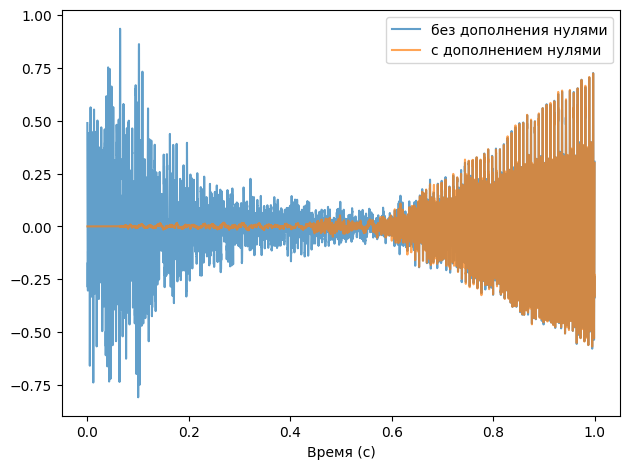

In [84]:
# Сравним оба результата

output_wrap.segment(duration=1).plot(label='без дополнения нулями', alpha=0.7)
output_padded.segment(duration=1).plot(label='с дополнением нулями', alpha=0.7)
decorate(xlabel='Время (с)')
plt.legend()

In [61]:
# Выводы:
# 1. Умножение ДПФ без zero padding реализует круговую свертку.
# 2. При круговой свертке конец сигнала "заворачивается" в начало,
#    поэтому в начале фрагмента появляется лишний звук.
# 3. Если дополнить сигнал нулями до длины N + M - 1,
#    круговая свертка становится эквивалентной линейной.
# 4. После zero padding лишняя нота в начале исчезает.
# 5. Значит, дополнение нулями — обязательный шаг,
#    если нужно получить корректную свертку через ДПФ.

In [62]:
# Упражнение 10.2
#
# Библиотека Open AIR содержит импульсные характеристики помещений.
# Нужно смоделировать звучание записи в выбранном пространстве
# двумя способами:
#
# 1. Сверткой записи с импульсной характеристикой.
# 2. Умножением ДПФ записи на фильтр, соответствующий импульсной
#    характеристике.
#
# В данном решении используются загруженные файлы:
# - alcuin_s2r1_bformat.wav — импульсная характеристика
# - modern-viola-c-major-slurred.wav — музыкальная запись

In [63]:
# Считаем оба файла.
# Импульсная характеристика многоканальная B-format,
# поэтому для простоты возьмем только первый канал.
# Запись альта стерео, поэтому переведем ее в моно усреднением.

framerate1, response_ys = wavfile.read('alcuin_s2r1_bformat.wav')
framerate2, wave_ys = wavfile.read('modern-viola-c-major-slurred.wav')

print(framerate1, response_ys.shape, response_ys.dtype)
print(framerate2, wave_ys.shape, wave_ys.dtype)

96000 (480001, 4) int32
96000 (2664950, 2) float32


/var/folders/wd/tn0z_gl176xb8mkdb0t85gt00000gn/T/ipykernel_5664/3147749095.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  framerate2, wave_ys = wavfile.read('modern-viola-c-major-slurred.wav')


In [64]:
# Проверим, что частоты дискретизации совпадают.

assert framerate1 == framerate2, "NO OK"
framerate = framerate1

In [65]:
# Преобразуем оба сигнала в одномерные массивы float.

response_ys = response_ys[:, 0].astype(float)

if wave_ys.ndim == 2:
    wave_ys = wave_ys.mean(axis=1)
wave_ys = wave_ys.astype(float)

In [66]:
# Нормализуем амплитуды.

response_ys /= np.max(np.abs(response_ys))
wave_ys /= np.max(np.abs(wave_ys))

In [67]:
# Создадим объекты Wave.

response = Wave(response_ys, framerate=framerate)
wave = Wave(wave_ys, framerate=framerate)

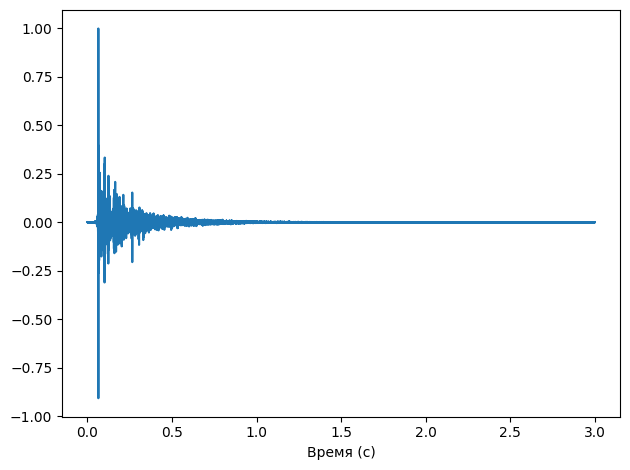

In [68]:
# Посмотрим на импульсную характеристику.
# Оставим только первые 3 секунды, этого достаточно для эксперимента.

response = response.segment(duration=3.0)
response.plot()
decorate(xlabel='Время (с)')

In [69]:
# Послушаем импульсную характеристику.

response.make_audio()

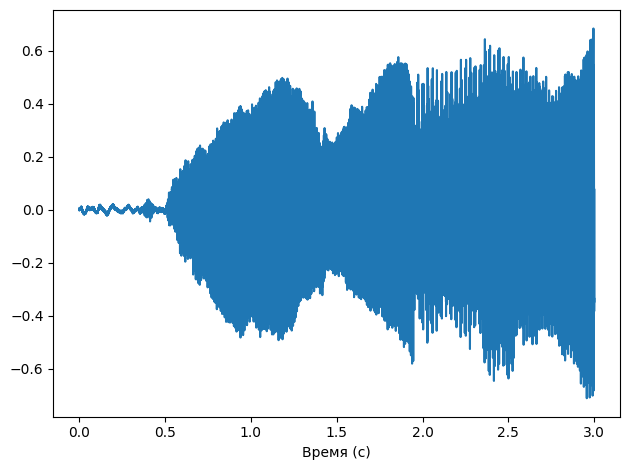

In [70]:
# Посмотрим на запись альта.
# Возьмем короткий фрагмент длиной 3 секунды.

wave = wave.segment(duration=3.0)
wave.plot()
decorate(xlabel='Время (с)')

In [71]:
# Послушаем исходную запись.

wave.make_audio()

In [72]:
# Для умножения спектров без циклического "заворачивания"
# надо дополнить сигналы нулями до длины N + M - 1.

n = len(wave.ys)
m = len(response.ys)
N = n + m - 1

wave2 = wave.copy()
response2 = response.copy()

wave2.zero_pad(N)
response2.zero_pad(N)

print(len(wave2.ys), len(response2.ys))

575999 575999


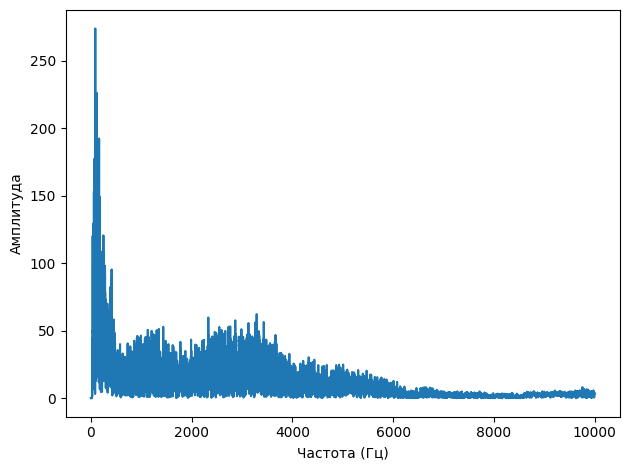

In [73]:
# Спектр импульсной характеристики — это передаточная функция фильтра.

transfer = response2.make_spectrum()
transfer.plot(high=10000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

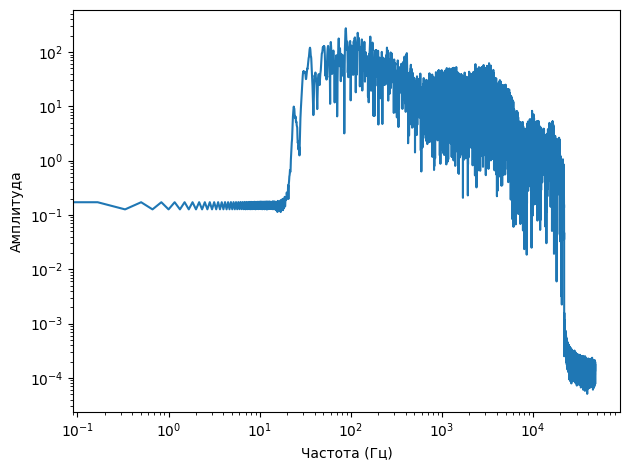

In [74]:
# Посмотрим на передаточную функцию в логарифмическом масштабе.

transfer.plot()
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда',
         xscale='log', yscale='log')

In [75]:
# Теперь вычислим спектр записи и умножим его на передаточную функцию.

spectrum = wave2.make_spectrum()
output_fft = (spectrum * transfer).make_wave()
output_fft.normalize()

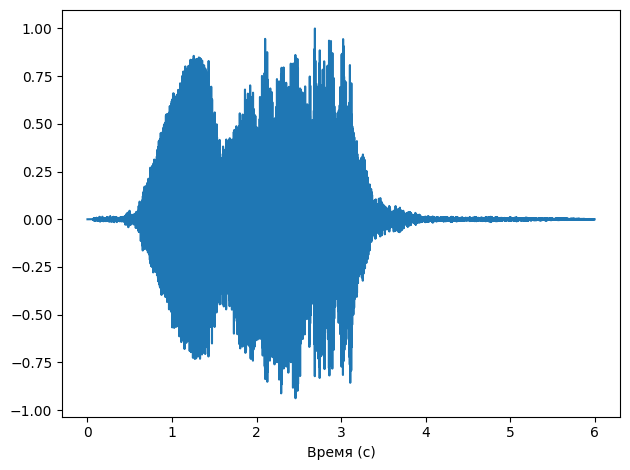

In [76]:
# Посмотрим на результат после преобразования в частотной области.

output_fft.plot()
decorate(xlabel='Время (с)')

In [77]:
# Послушаем результат.

output_fft.make_audio()

In [78]:
# Теперь выполним линейную свертку во временной области.

output_conv = wave.convolve(response)
output_conv.normalize()

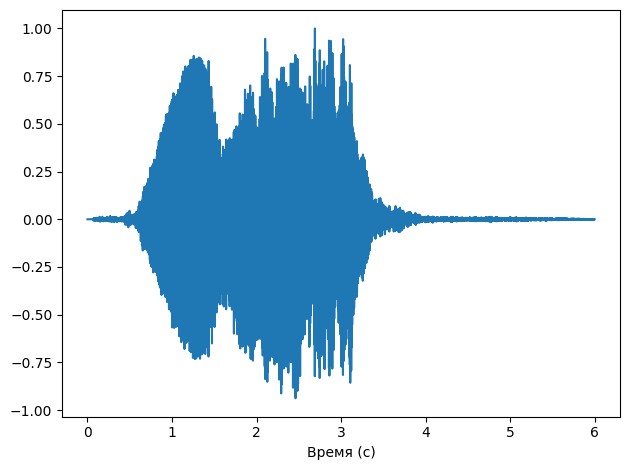

In [79]:
# Посмотрим на результат свертки.

output_conv.plot()
decorate(xlabel='Время (с)')

In [80]:
# И послушаем его.

output_conv.make_audio()

In [81]:
# Выводы:
# 1. Импульсная характеристика задает акустические свойства пространства.
# 2. Свертка записи с импульсной характеристикой моделирует,
#    как этот звук прозвучал бы в данном помещении.
# 3. Умножение спектра записи на передаточную функцию фильтра
#    дает тот же результат, если правильно использовать дополнение нулями.
# 4. Без zero padding результат в частотной области был бы испорчен
#    циклической сверткой.
# 5. Практически оба способа эквивалентны, но частотный способ
#    особенно удобен для длинных сигналов и длинных импульсных характеристик.